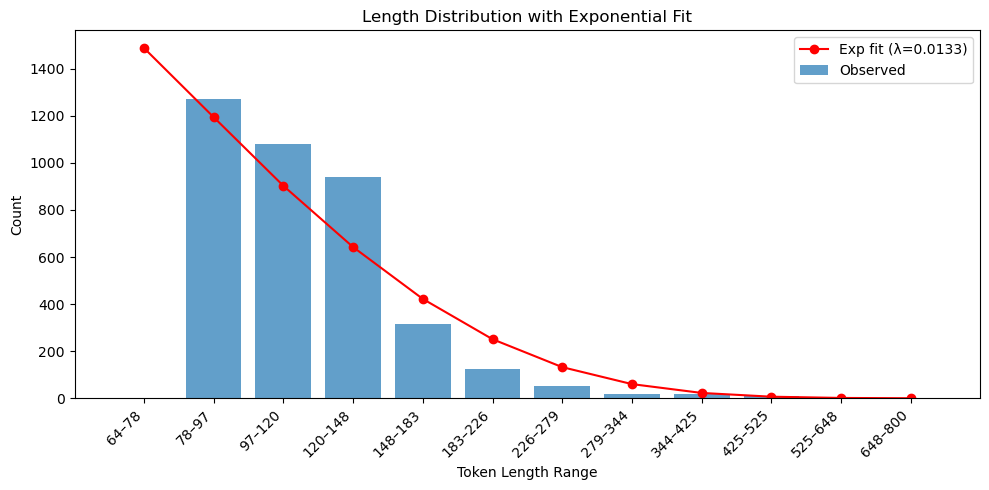

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Your observed bins and counts
bin_labels = [
    "64–78", "78–97", "97–120", "120–148", "148–183",
    "183–226", "226–279", "279–344", "344–425",
    "425–525", "525–648", "648–800"
]
counts = np.array([0, 1273, 1081, 939, 314, 124, 51, 20, 18, 10, 3, 3])

# Parse the ranges
lows = np.array([int(lbl.split('–')[0]) for lbl in bin_labels])
highs = np.array([int(lbl.split('–')[1]) for lbl in bin_labels])
mids = (lows + highs) / 2

# Total samples
N = counts.sum()

# Estimate lambda = 1 / sample mean (approximate mean by midpoint weighted)
sample_mean =  75
lam = 1 / sample_mean

# Compute expected count in each bin exactly:
#   P(low < X <= high) = exp(-λ·low) – exp(-λ·high)
probs = np.exp(-lam * mids)
expecteds = N * probs

# Plot
plt.figure(figsize=(10,5))

# 1) observed histogram
x = np.arange(len(bin_labels))
plt.bar(x, counts, label="Observed", alpha=0.7)

# 2) fitted exp “pdf” as red line at bin midpoints
plt.plot(x, expecteds, color='red', marker='o',
         linestyle='-', label=f"Exp fit (λ={lam:.4f})")

# Labels & legend
plt.xticks(x, bin_labels, rotation=45, ha='right')
plt.xlabel("Token Length Range")
plt.ylabel("Count")
plt.title("Length Distribution with Exponential Fit")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# FAILED GOODNESS OF FIT TEST
import numpy as np
from scipy.stats import chi2

# Observed data
# merge labels so that each count is at least 5
bin_labels = [
     "78–97", "97–120", "120–148", "148–183",
    "183–226", "226–279", "279–344", "344–425",
    "425–525", "525–800"
]
obs = np.array([ 1273, 1081, 939, 314, 124, 51, 20, 18, 10, 6])
N = obs.sum()

# Parse numeric bin edges
lows  = np.array([int(lbl.split('–')[0]) for lbl in bin_labels])
highs = np.array([int(lbl.split('–')[1]) for lbl in bin_labels])
mids  = (lows + highs) / 2

# Estimate lambda via sample mean
sample_mean = np.sum(mids * obs) / N
lam = 1 / sample_mean

# Compute expected counts under Exp(lam)
probs = np.exp(-lam * lows) - np.exp(-lam * highs)
exp_counts = N * probs
exp_counts *= N / exp_counts.sum()

mask = exp_counts > 0
obs_filt = obs[mask]
exp_filt = exp_counts[mask]

# Merge any very small expected bins (if <5) with neighbors to satisfy χ² assumptions
# For simplicity, here we’ll drop bins with exp<5 and combine them into the last bin:
mask = exp_counts >= 5
obs2 = np.append(obs[mask], obs[~mask].sum())
exp2 = np.append(exp_counts[mask], exp_counts[~mask].sum())

# 4) Compute χ² statistic by hand
chi2_stat = np.sum((obs - exp_counts)**2 / exp_counts)

# Degrees of freedom: #bins − 1 (for sum constraint) − 1 (for estimated λ)
df = len(obs) - 1 - 1

# 5) Compute p‐value from chi‐square distribution
p_value = chi2.sf(chi2_stat, df)

print(f"Estimated λ = {lam:.4f}")
print(f"χ² statistic = {chi2_stat:.2f}")
print(f"Degrees of freedom = {df}")
print(f"p‐value = {p_value:.8f}")

Estimated λ = 0.0082
χ² statistic = 2938.29
Degrees of freedom = 8
p‐value = 0.00000000


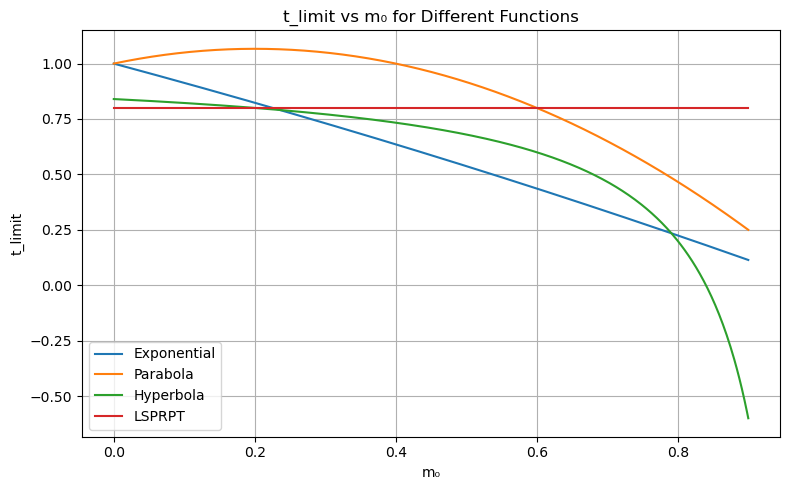

In [15]:
# TODO: draw the following graphs on the same set of axes
# m0 from 0 to 1 vs t_limit
# Exponential: t_limit =(1 - math.exp(-0.3 + 0.3 * m0)) / (1 - math.exp(-0.3))
# Parabola: t_limit = -0.4761904762 * m0 **2  -1.4761904762 * m0  + 1
# Hyperbola: t_limit = -0.16 / (m0 - 1) + 1
# LSPRPT: t_limit = 0.8

import numpy as np
import matplotlib.pyplot as plt

# Define m0 range from 0 to just before 1 to avoid the hyperbola singularity
m0 = np.linspace(0, 0.9, 500)

# Compute t_limit for each function
t_exp = (1 - np.exp(-0.3 + 0.3 * m0)) / (1 - np.exp(-0.3))
t_par = -5/3 * m0**2 +2/3 * m0 + 1
t_hyp = 0.16 / (m0 - 1) + 1
t_ls  = np.full_like(m0, 0.8)

# Plot all curves on the same axes
plt.figure(figsize=(8, 5))
plt.plot(m0, t_exp, label='Exponential')
plt.plot(m0, t_par, label='Parabola')
plt.plot(m0, t_hyp, label='Hyperbola')
plt.plot(m0, t_ls,  label='LSPRPT')

# Labels and styling
plt.xlabel('m₀')
plt.ylabel('t_limit')
plt.title('t_limit vs m₀ for Different Functions')
plt.legend()
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()
